In [1]:
# Import required libraries

import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display plots inside the notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Connect to the SQLite database

conn = sqlite3.connect("cricsheet.db")
cursor = conn.cursor()

print("Connected to SQLite database successfully.")

Connected to SQLite database successfully.


In [3]:
# Step 3: Load Tables into Pandas DataFrames

# Load tables from SQLite into Pandas DataFrames

matches_df = pd.read_sql_query("SELECT * FROM matches", conn)
deliveries_df = pd.read_sql_query("SELECT * FROM deliveries", conn)

print("Tables loaded successfully.\n")

print("Matches Table Shape:", matches_df.shape)
print("Deliveries Table Shape:", deliveries_df.shape)

Tables loaded successfully.

Matches Table Shape: (5641, 15)
Deliveries Table Shape: (3799833, 15)


In [4]:
# Step 4: Display the First 5 Records

# Preview the Dataset

# Display the first 5 rows of both tables

print("Matches Table (First 5 Rows):")
display(matches_df.head())

print("\nDeliveries Table (First 5 Rows):")
display(deliveries_df.head())

Matches Table (First 5 Rows):


,match_id,match_type,gender,event_name,match_date,team1,team2,venue,city,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match
0,1082591,T20,male,Indian Premier League,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh
1,1082592,T20,male,Indian Premier League,2017-04-06,Rising Pune Supergiant,Mumbai Indians,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,field,Rising Pune Supergiant,NaN,7.0,SPD Smith
2,1082593,T20,male,Indian Premier League,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Saurashtra Cricket Association Stadium,Rajkot,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,CA Lynn
3,1082594,T20,male,Indian Premier League,2017-04-08,Kings XI Punjab,Rising Pune Supergiant,Holkar Cricket Stadium,Indore,Kings XI Punjab,field,Kings XI Punjab,NaN,6.0,GJ Maxwell
4,1082595,T20,male,Indian Premier League,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,15.0,NaN,KM Jadhav



Deliveries Table (First 5 Rows):


,id,match_id,innings,over_number,ball_number,batting_team,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,wicket,wicket_kind,player_out
0,1,1082591,1,0,1,Sunrisers Hyderabad,DA Warner,TS Mills,S Dhawan,0,0,0,0,None,None
1,2,1082591,1,0,2,Sunrisers Hyderabad,DA Warner,TS Mills,S Dhawan,0,0,0,0,None,None
2,3,1082591,1,0,3,Sunrisers Hyderabad,DA Warner,TS Mills,S Dhawan,4,0,4,0,None,None
3,4,1082591,1,0,4,Sunrisers Hyderabad,DA Warner,TS Mills,S Dhawan,0,0,0,0,None,None
4,5,1082591,1,0,5,Sunrisers Hyderabad,DA Warner,TS Mills,S Dhawan,0,2,2,0,None,None


In [5]:
# Step 5: Display Column Names

# Display column names for both tables

print("Matches Table Columns:\n")
print(matches_df.columns.tolist())

print("\n" + "=" * 60 + "\n")

print("Deliveries Table Columns:\n")
print(deliveries_df.columns.tolist())

Matches Table Columns:

['match_id', 'match_type', 'gender', 'event_name', 'match_date', 'team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match']


Deliveries Table Columns:

['id', 'match_id', 'innings', 'over_number', 'ball_number', 'batting_team', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'wicket', 'wicket_kind', 'player_out']


In [6]:
# Step 6: Check Data Types

# Display data types of all columns

print("Matches Table Data Types:\n")
print(matches_df.dtypes)

print("\n" + "=" * 60 + "\n")

print("Deliveries Table Data Types:\n")
print(deliveries_df.dtypes)

Matches Table Data Types:

match_id            object
match_type          object
gender              object
event_name          object
match_date          object
team1               object
team2               object
venue               object
city                object
toss_winner         object
toss_decision       object
winner              object
win_by_runs        float64
win_by_wickets     float64
player_of_match     object
dtype: object


Deliveries Table Data Types:

id               int64
match_id        object
innings          int64
over_number      int64
ball_number      int64
batting_team    object
batter          object
bowler          object
non_striker     object
runs_batter      int64
runs_extras      int64
runs_total       int64
wicket           int64
wicket_kind     object
player_out      object
dtype: object


In [7]:
# Step 7: Display Dataset Information

# Display detailed information about the datasets

print("Matches Table Information:\n")
matches_df.info()

print("\n" + "=" * 70 + "\n")

print("Deliveries Table Information:\n")
deliveries_df.info()

Matches Table Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5641 entries, 0 to 5640
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         5641 non-null   object 
 1   match_type       5641 non-null   object 
 2   gender           5641 non-null   object 
 3   event_name       5618 non-null   object 
 4   match_date       5641 non-null   object 
 5   team1            5641 non-null   object 
 6   team2            5641 non-null   object 
 7   venue            5641 non-null   object 
 8   city             5148 non-null   object 
 9   toss_winner      5641 non-null   object 
 10  toss_decision    5641 non-null   object 
 11  winner           5277 non-null   object 
 12  win_by_runs      2672 non-null   float64
 13  win_by_wickets   2604 non-null   float64
 14  player_of_match  5641 non-null   object 
dtypes: float64(2), object(13)
memory usage: 661.2+ KB


Deliveries Table Informati

In [8]:
# Step 8: Summary Statistics

# Display summary statistics for numerical columns

print("Matches Table Summary Statistics:\n")
display(matches_df.describe())

print("\n" + "=" * 70 + "\n")

print("Deliveries Table Summary Statistics:\n")
display(deliveries_df.describe())

Matches Table Summary Statistics:



,win_by_runs,win_by_wickets
count,2672.000000,2604.000000
mean,80.002620,6.031106
std,75.400682,2.171700
min,1.000000,1.000000
25%,23.000000,5.000000
50%,58.000000,6.000000
75%,114.000000,8.000000
max,492.000000,10.000000




Deliveries Table Summary Statistics:



,id,innings,over_number,ball_number,runs_batter,runs_extras,runs_total,wicket
count,3.799833e+06,3.799833e+06,3.799833e+06,3.799833e+06,3.799833e+06,3.799833e+06,3.799833e+06,3.799833e+06
mean,1.899917e+06,1.796263e+00,3.447930e+01,3.566624e+00,6.983731e-01,4.154814e-02,7.399212e-01,2.472135e-02
std,1.096917e+06,8.696737e-01,3.162333e+01,1.768060e+00,1.245842e+00,2.846864e-01,1.257794e+00,1.552746e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.499590e+05,1.000000e+00,1.200000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.899917e+06,2.000000e+00,2.600000e+01,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.849875e+06,2.000000e+00,4.500000e+01,5.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,3.799833e+06,6.000000e+00,2.480000e+02,1.400000e+01,8.000000e+00,7.000000e+00,8.000000e+00,1.000000e+00


In [9]:
# Step 9: Check Missing Values

# Check missing values in both datasets

print("Missing Values in Matches Table:\n")
display(matches_df.isnull().sum())

print("\n" + "=" * 70 + "\n")

print("Missing Values in Deliveries Table:\n")
display(deliveries_df.isnull().sum())

Missing Values in Matches Table:



match_id              0
match_type            0
gender                0
event_name           23
match_date            0
team1                 0
team2                 0
venue                 0
city                493
toss_winner           0
toss_decision         0
winner              364
win_by_runs        2969
win_by_wickets     3037
player_of_match       0
dtype: int64



Missing Values in Deliveries Table:



id                    0
match_id              0
innings               0
over_number           0
ball_number           0
batting_team          0
batter                0
bowler                0
non_striker           0
runs_batter           0
runs_extras           0
runs_total            0
wicket                0
wicket_kind     3705896
player_out      3705896
dtype: int64

In [10]:
# Step 10: Check Duplicate Records

# Check duplicate records in both datasets

print("Duplicate Rows in Matches Table:")
print(matches_df.duplicated().sum())

print("\n" + "=" * 50 + "\n")

print("Duplicate Rows in Deliveries Table:")
print(deliveries_df.duplicated().sum())

Duplicate Rows in Matches Table:
0


Duplicate Rows in Deliveries Table:
0


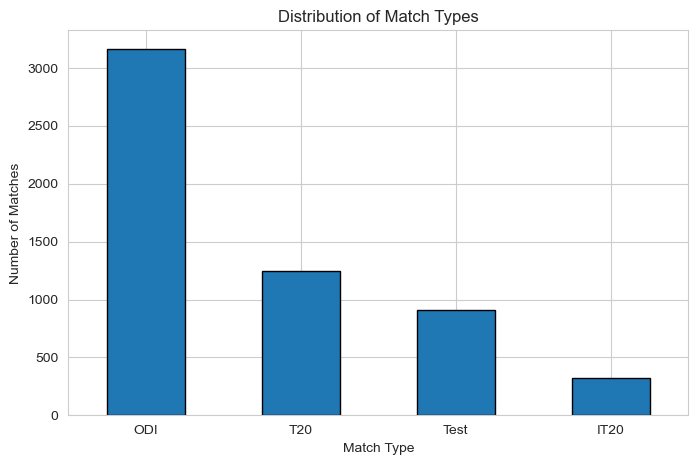

In [11]:
# Step 11: Distribution of Match Types

# Distribution of Match Types

plt.figure(figsize=(8, 5))

matches_df["match_type"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Match Types")
plt.xlabel("Match Type")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.show()

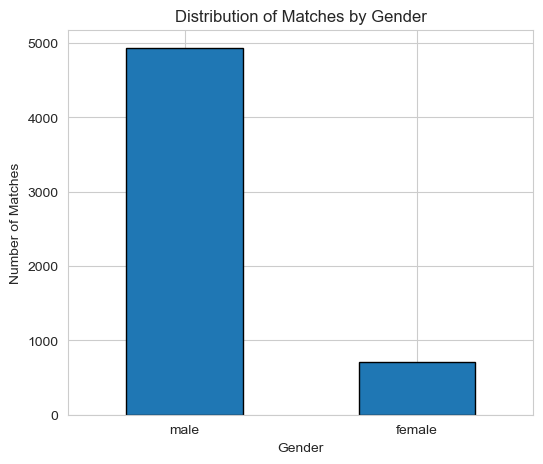

In [12]:
# Step 12: Distribution of Gender

# Distribution of Men's and Women's Matches

plt.figure(figsize=(6, 5))

matches_df["gender"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Matches by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.show()

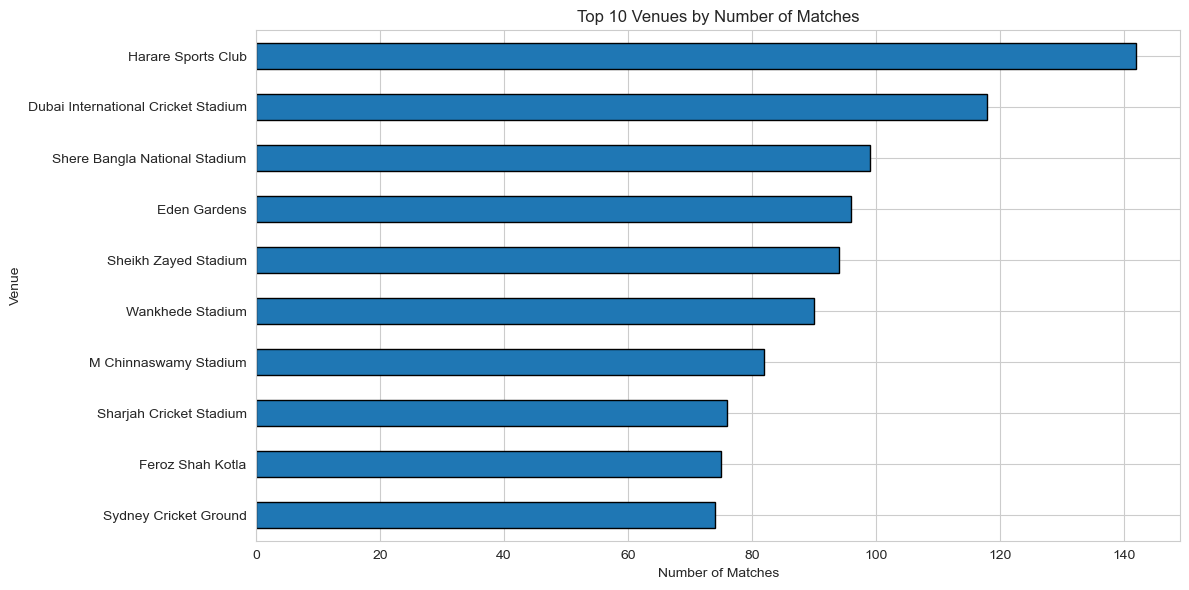

In [13]:
# Step 13: Top 10 Venues by Number of Matches

# Step 13: Top 10 Venues by Number of Matches

top_venues = matches_df["venue"].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_venues.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

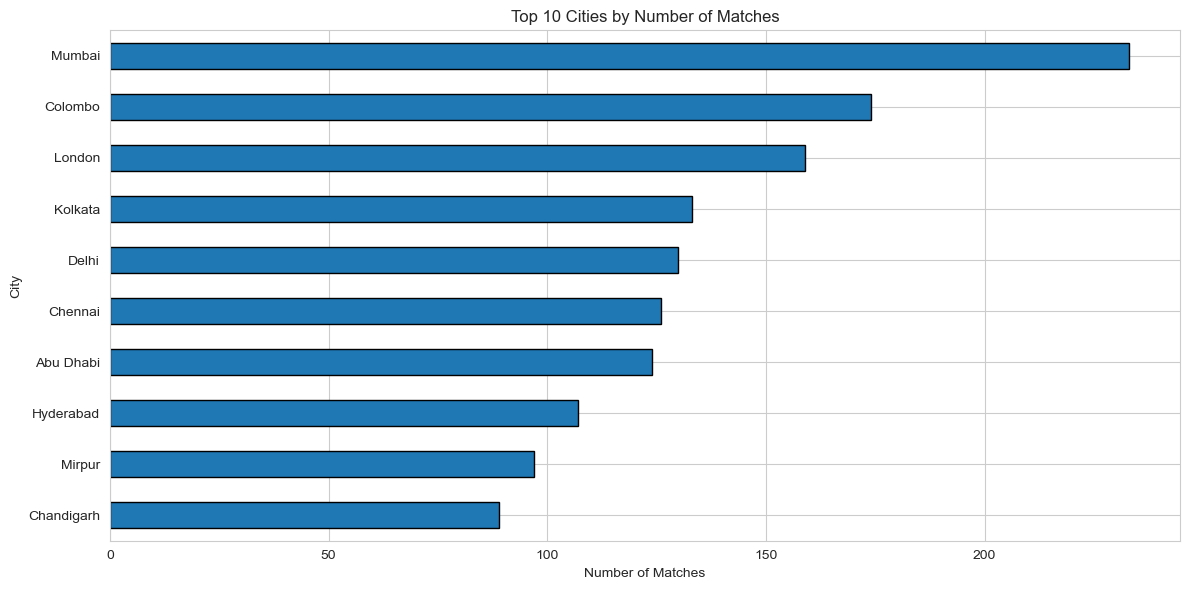

In [14]:
# Step 14: Top 10 Cities by Number of Matches

# Top 10 cities by number of matches

top_cities = matches_df["city"].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_cities.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Cities by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("City")

plt.tight_layout()
plt.show()

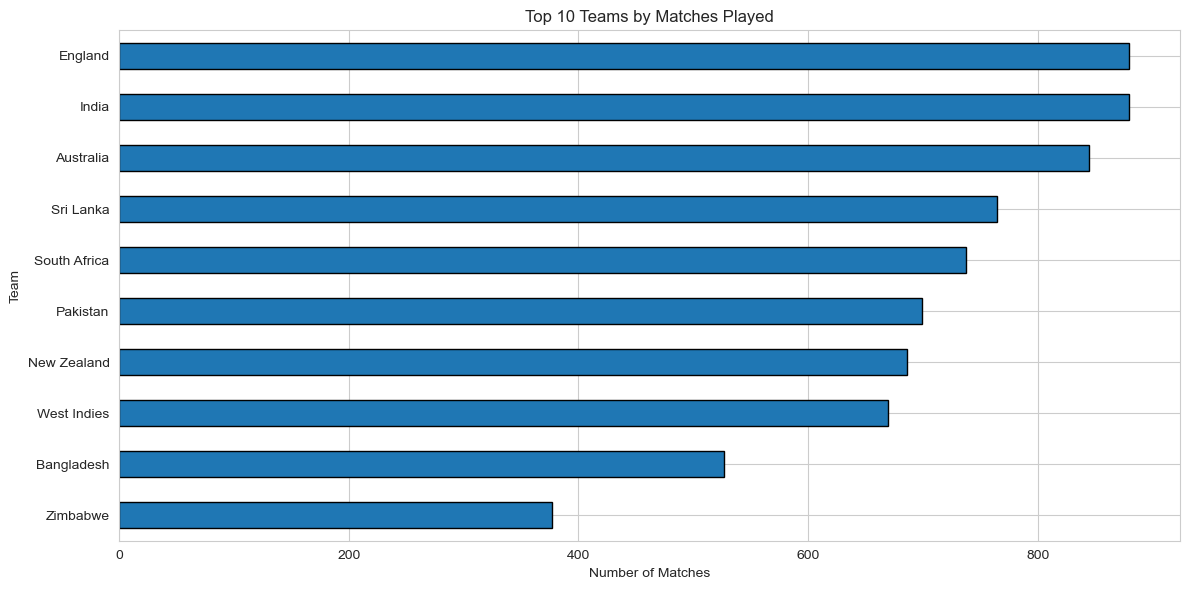

In [15]:
# Step 15: Top 10 Teams by Matches Played

# Top 10 teams by matches played

all_teams = pd.concat([matches_df["team1"], matches_df["team2"]])

top_teams = all_teams.value_counts().head(10)

plt.figure(figsize=(12, 6))

top_teams.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Teams by Matches Played")
plt.xlabel("Number of Matches")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

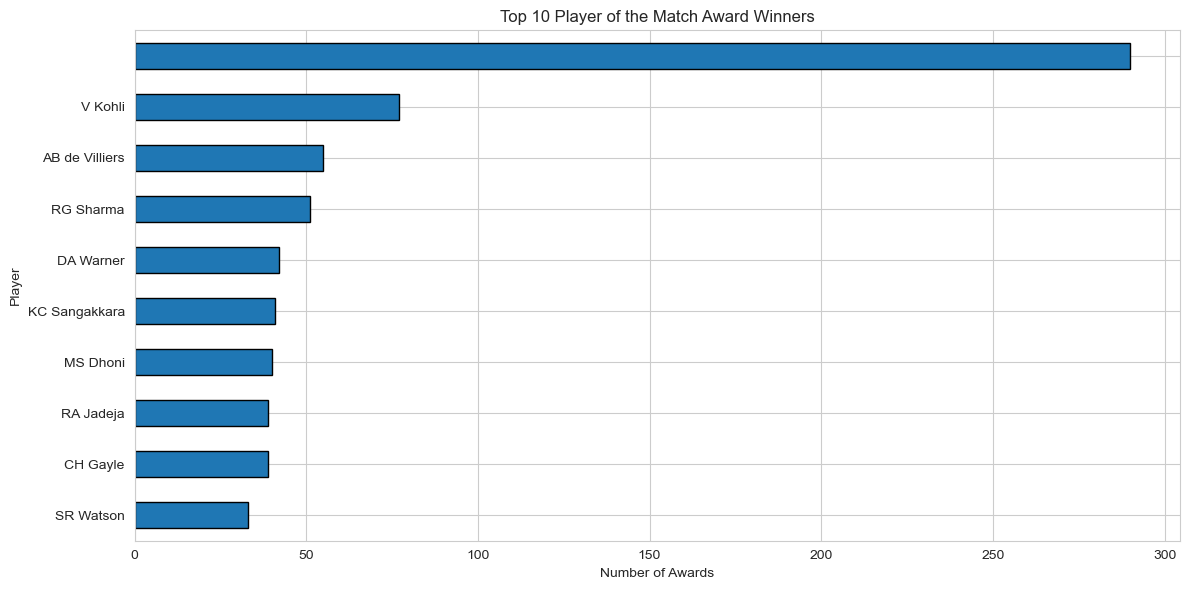

In [16]:
# Step 16: Top 10 Players with Most Player of the Match Awards

# Top 10 Player of the Match award winners

top_players = matches_df["player_of_match"].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_players.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Player of the Match Award Winners")
plt.xlabel("Number of Awards")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

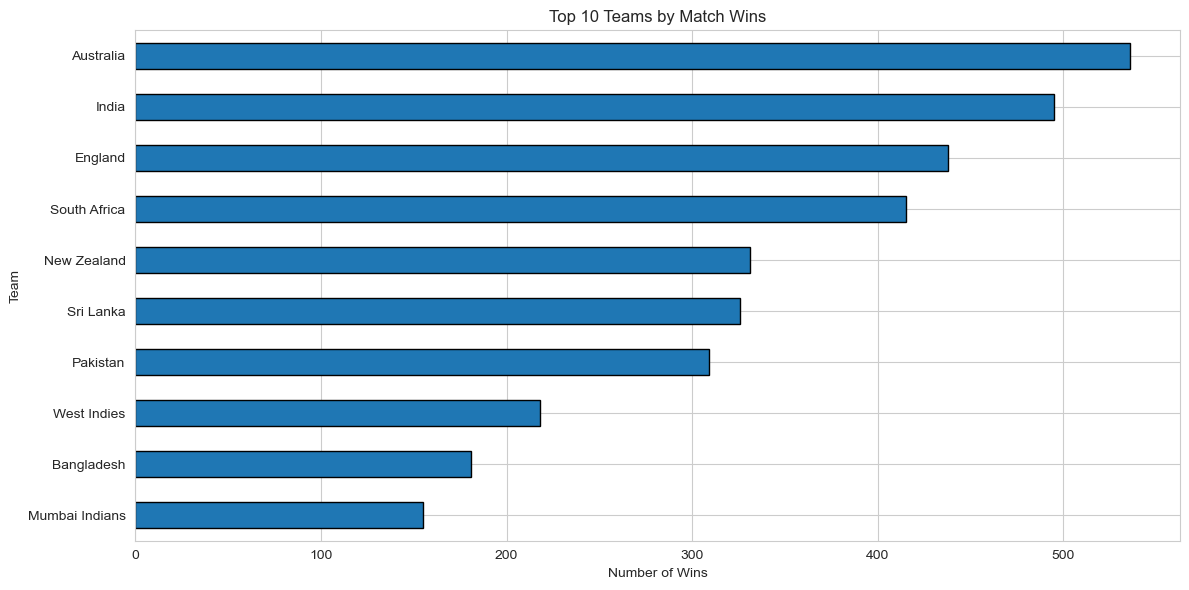

In [17]:
# Step 17: Top 10 Winning Teams

# Top 10 teams by match wins

top_winners = matches_df["winner"].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_winners.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

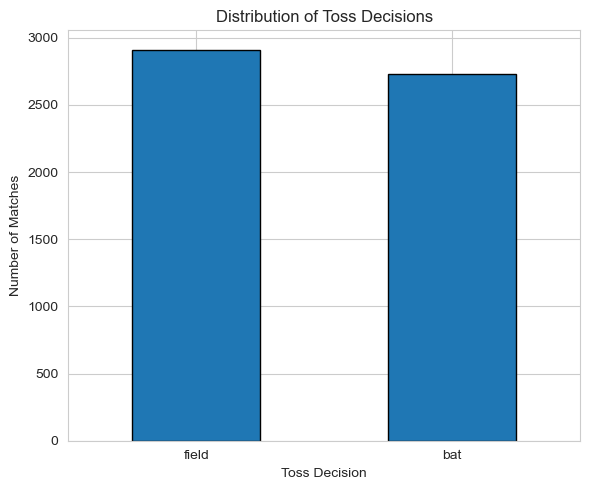

In [18]:
# Step 18: Toss Decision Distribution

# Distribution of Toss Decisions

plt.figure(figsize=(6, 5))

matches_df["toss_decision"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Toss Decisions")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

,No Result,Completed Match
toss_decision,,
bat,199,2533
field,165,2744


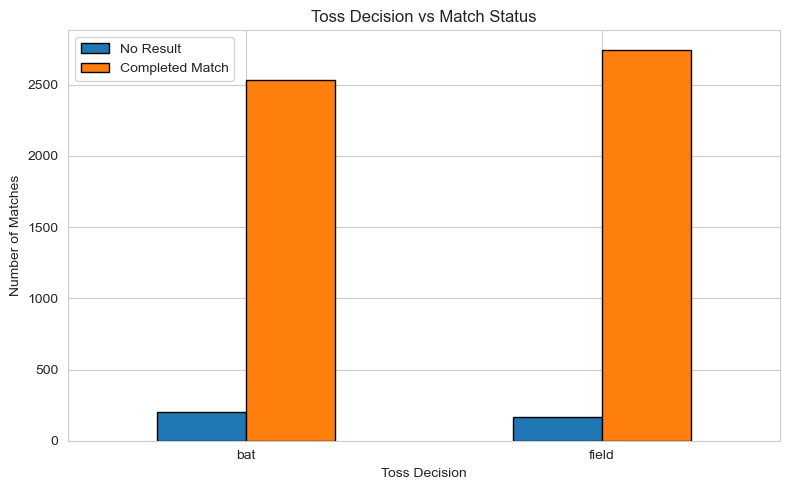

In [19]:
# Step 19: Toss Decision vs Match Wins

# Toss Decision vs Match Outcomes

toss_vs_winner = pd.crosstab(
    matches_df["toss_decision"],
    matches_df["winner"].notna()
)

toss_vs_winner.columns = ["No Result", "Completed Match"]

display(toss_vs_winner)

toss_vs_winner.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Toss Decision vs Match Status")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

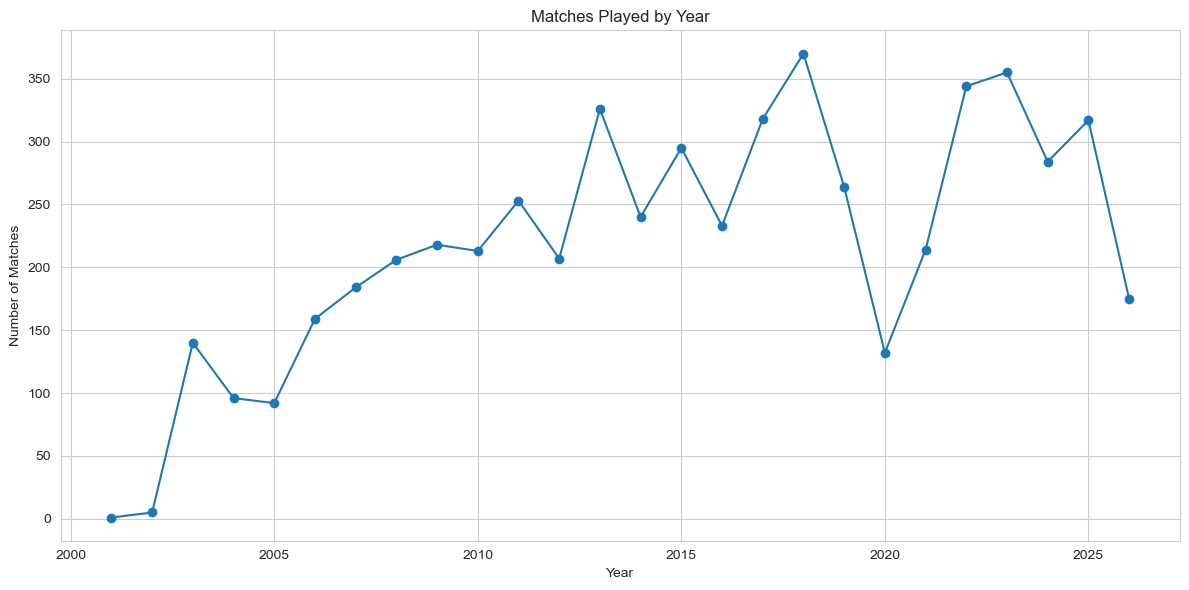

In [20]:
# Step 20: Matches Played by Year

# Convert match_date to datetime

matches_df["match_date"] = pd.to_datetime(matches_df["match_date"])

# Extract year
matches_df["year"] = matches_df["match_date"].dt.year

# Matches played by year
matches_per_year = matches_df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

matches_per_year.plot(
    kind="line",
    marker="o"
)

plt.title("Matches Played by Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.grid(True)

plt.tight_layout()
plt.show()

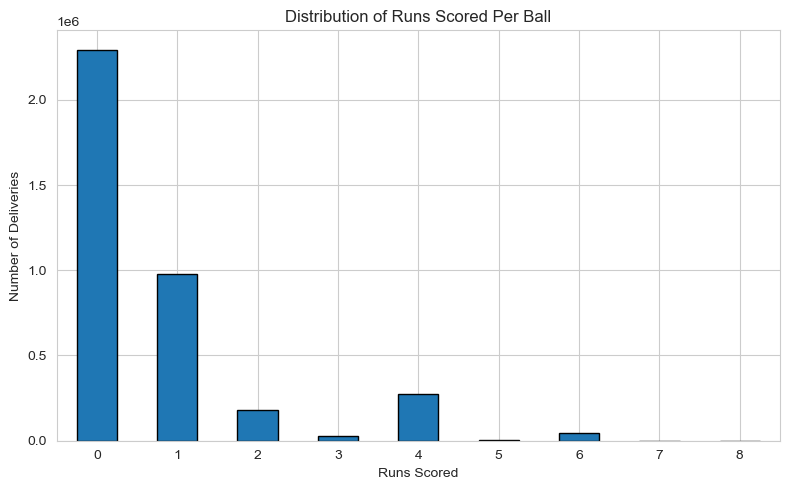

In [21]:
# Step 21: Distribution of Runs Scored Per Ball

# Distribution of runs scored per ball

plt.figure(figsize=(8, 5))

deliveries_df["runs_total"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Runs Scored Per Ball")
plt.xlabel("Runs Scored")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

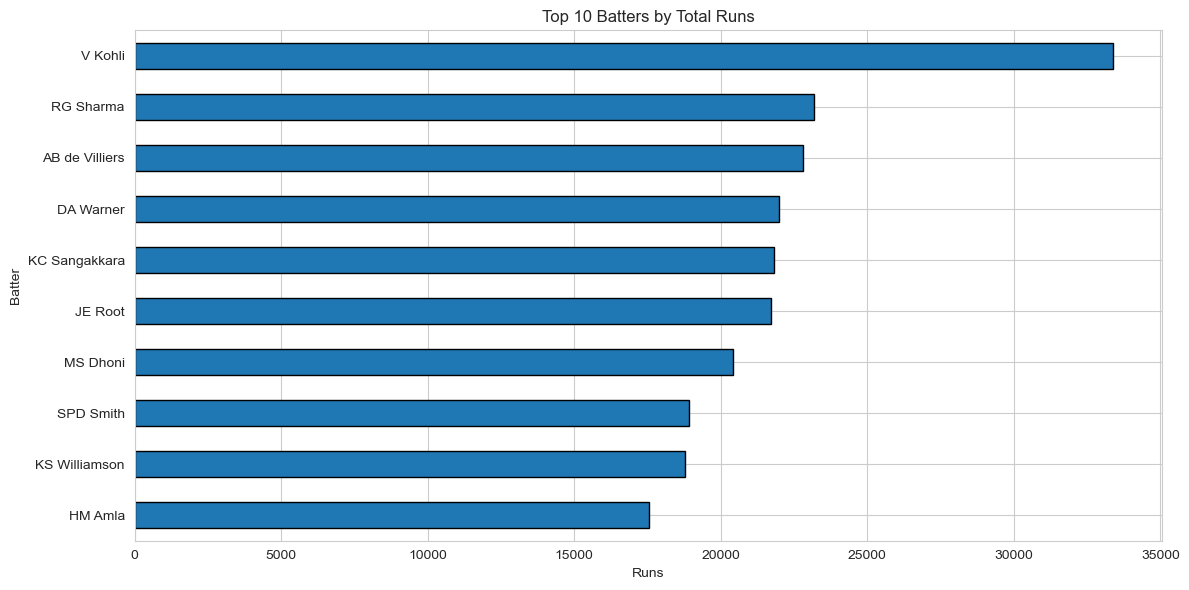

In [22]:
# Step 22 — Top 10 Batters by Total Runs

# Step 22: Top 10 Batters by Total Runs

top_batters = (
    deliveries_df.groupby("batter")["runs_batter"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_batters.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Batters by Total Runs")
plt.xlabel("Runs")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

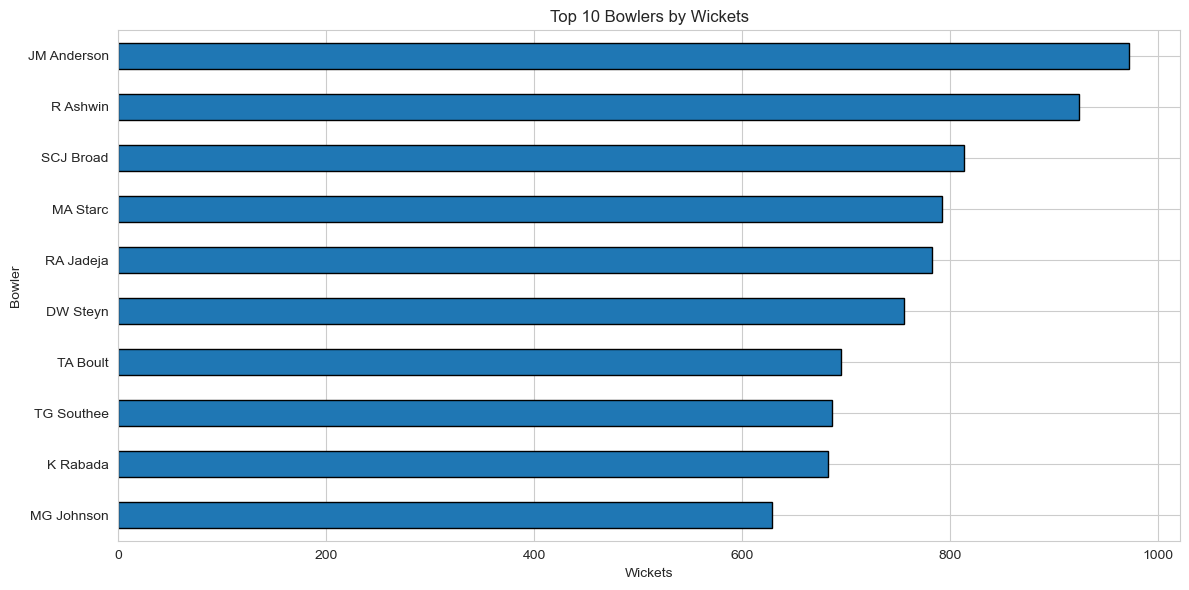

In [23]:
# Step 23: Top 10 Bowlers by Wickets

# Step 23: Top 10 Bowlers by Wickets

top_bowlers = (
    deliveries_df[deliveries_df["wicket"] == 1]
    .groupby("bowler")["wicket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_bowlers.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Bowlers by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

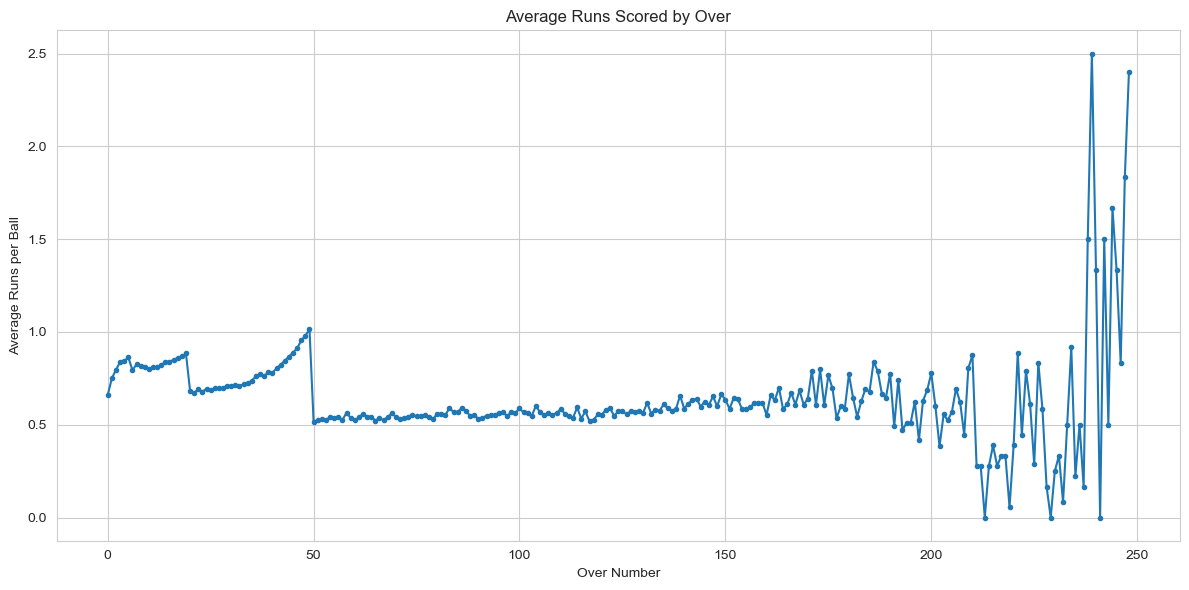

In [24]:
# Step 24: Runs Scored by Over

# Step 24: Average Runs Scored by Over

runs_by_over = (
    deliveries_df.groupby("over_number")["runs_total"]
    .mean()
)

plt.figure(figsize=(12, 6))

runs_by_over.plot(
    kind="line",
    marker="."
)

plt.title("Average Runs Scored by Over")
plt.xlabel("Over Number")
plt.ylabel("Average Runs per Ball")

plt.grid(True)
plt.tight_layout()
plt.show()

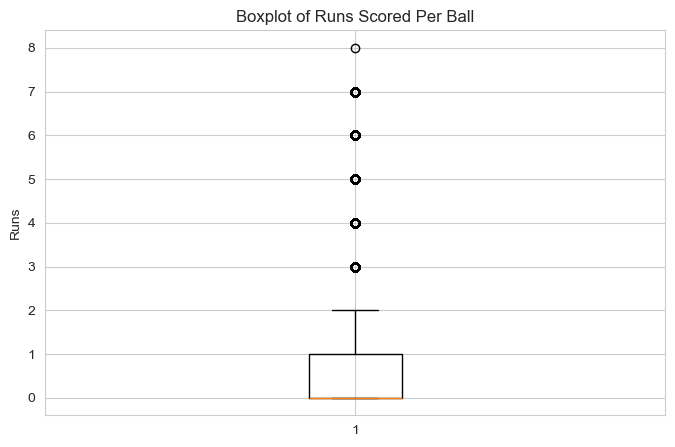

In [25]:
# Step 25: Outlier Analysis (Boxplot)

# Step 25: Boxplot for Runs Scored Per Ball

plt.figure(figsize=(8, 5))

plt.boxplot(deliveries_df["runs_total"])

plt.title("Boxplot of Runs Scored Per Ball")
plt.ylabel("Runs")

plt.show()

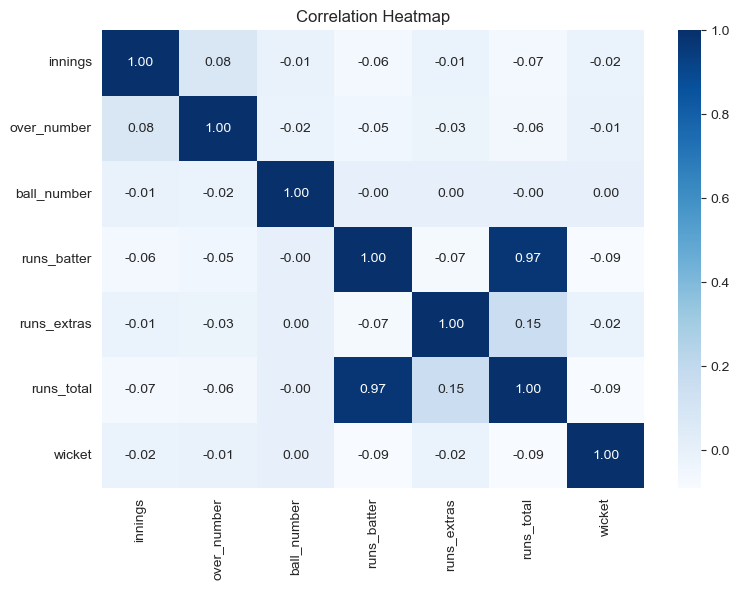

In [26]:
# Step 26: Correlation Heatmap

numeric_columns = [
    "innings",
    "over_number",
    "ball_number",
    "runs_batter",
    "runs_extras",
    "runs_total",
    "wicket"
]

corr = deliveries_df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# Business Insights

1. ODI is the most frequently played match format in the dataset.

2. Male cricket accounts for the majority of recorded matches.

3. Mumbai is the city that has hosted the highest number of matches.

4. Harare Sports Club is the venue with the highest number of matches.

5. Australia has won the most matches in the dataset.

6. Virat Kohli is the highest run scorer among all batters.

7. James Anderson has taken the highest number of wickets.

8. Dot balls (0 runs) are the most common outcome for a delivery.

9. Teams choose to field slightly more often after winning the toss.

10. Cricket activity has generally increased over the years, with a temporary decline around 2020.

In [27]:
# Close database connection

conn.close()

print("Database connection closed successfully.")

Database connection closed successfully.
